In [1]:
import openai
import whisper
import torch
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
import time
import json
import re
import transformers
import stable_whisper # https://github.com/jianfch/stable-ts
import tqdm

load_dotenv()
assert os.environ.get('OPENAI_API_KEY')

/Users/vincentlin246/git/adaptive-language-controller/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# global constants

DATA_FP = 'data'
DELTA_T = 0.2 # seconds

# Data Processing

## Alignment strategies

* alignment by fixed time bucket size
    * average pose/force data across fixed time length (e.g. 0.25 sec) buckets
    * use whisper word segments to assign words to buckets 

* alignment by word segments
    * obtain word segments, including silence
    * assign each pose/force reading to its designated word
    * bucketize/average within each word to align pose/force data? fixed number of buckets or fixed time interval? 

* alignment by trajectory segments

## Util

In [3]:
# from https://stackoverflow.com/questions/26646362/numpy-array-is-not-json-serializable
# for json dumping np arrays

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)

## Audio data processing

In [4]:
model = whisper.load_model('base')
audio_fp = 'data/lightbuzz_table_1/cut_audio.wav'

start = time.time()
transcription = model.transcribe(audio_fp, word_timestamps=True)
print(f'Time elapsed for transcription: {round(time.time() - start, 2)}')

print(transcription['text'])

/Users/vincentlin246/git/adaptive-language-controller/venv/lib/python3.11/site-packages/whisper/transcribe.py:115: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Time elapsed for transcription: 12.13
 One, two, three go. All right, I want you to come towards myself. Keep coming towards me. Keep coming towards me. You're doing very good. Now I want you to move your hand towards yourself this time. So move towards yourself. Move towards your self, like wiping the table. Now I want you to move towards myself. So keep moving towards myself. Keep moving your hand towards myself. And this time I want to guide you so that you can move your hand towards your side. So slide your hand towards your side. Slide your hand towards your side. Keep moving and that's good.


In [5]:
tr = model.transcribe('hat.wav', word_timestamps=True)
print(json.dumps(tr, indent=2))

/Users/vincentlin246/git/adaptive-language-controller/venv/lib/python3.11/site-packages/whisper/transcribe.py:115: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


{
  "text": " Hat",
  "segments": [
    {
      "id": 0,
      "seek": 0,
      "start": 0.0,
      "end": 1.26,
      "text": " Hat",
      "tokens": [
        50364,
        15867,
        50439
      ],
      "temperature": 1.0,
      "avg_logprob": -2.0304017066955566,
      "compression_ratio": 0.2727272727272727,
      "no_speech_prob": 0.24766065180301666,
      "words": [
        {
          "word": " Hat",
          "start": 0.0,
          "end": 1.26,
          "probability": 0.659905731678009
        }
      ]
    }
  ],
  "language": "en"
}


In [6]:
print(json.dumps(transcription, indent=2))

{
  "text": " One, two, three go. All right, I want you to come towards myself. Keep coming towards me. Keep coming towards me. You're doing very good. Now I want you to move your hand towards yourself this time. So move towards yourself. Move towards your self, like wiping the table. Now I want you to move towards myself. So keep moving towards myself. Keep moving your hand towards myself. And this time I want to guide you so that you can move your hand towards your side. So slide your hand towards your side. Slide your hand towards your side. Keep moving and that's good.",
  "segments": [
    {
      "id": 0,
      "seek": 0,
      "start": 0.0,
      "end": 1.62,
      "text": " One, two, three go.",
      "tokens": [
        50364,
        1485,
        11,
        732,
        11,
        1045,
        352,
        13,
        50469
      ],
      "temperature": 0.0,
      "avg_logprob": -0.21037555623937537,
      "compression_ratio": 2.17816091954023,
      "no_speech_prob": 0.2

(array([ 1.,  0.,  3.,  8.,  3.,  5.,  4.,  8.,  7.,  5.,  3.,  7.,  5.,
         5., 11.,  6.,  2.,  4.,  1.,  2.,  0.,  3.,  0.,  0.,  0.,  1.,
         3.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,  2.,  2.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.02  , 0.0428, 0.0656, 0.0884, 0.1112, 0.134 , 0.1568, 0.1796,
        0.2024, 0.2252, 0.248 , 0.2708, 0.2936, 0.3164, 0.3392, 0.362 ,
        0.3848, 0.4076, 0.4304, 0.4532, 0.476 , 0.4988, 0.5216, 0.5444,
        0.5672, 0.59  , 0.6128, 0.6356, 0.6584, 0.6812, 0.704 , 0.7268,
        0.7496, 0.7724, 0.7952, 0.818 , 0.8408, 0.8636, 0.8864, 0.9092,
        0.932 , 0.9548, 0.9776, 1.0004, 1.0232, 1.046 , 1.0688, 1.0916,
        1.1144, 1.1372, 1.16  ]),
 <BarContainer object of 50 artists>)

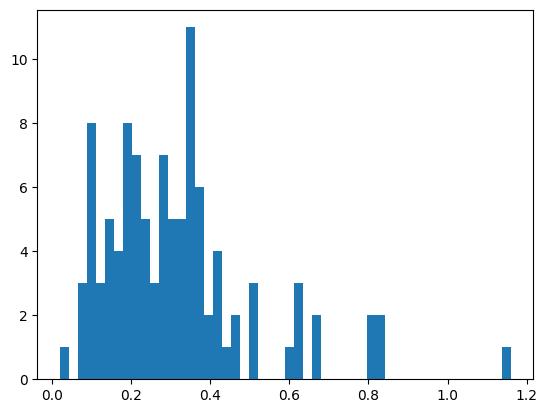

In [7]:
# analyze distribution of word lengths. pick delta_t to ensure that not too many
# words land in the same bin as another word , i.e. bins -> words is (mostly) injective

intervals = []
for segment in transcription['segments']:
    for word_data in segment['words']:
        intervals.append(word_data['end'] - word_data['start'])

plt.hist(intervals, bins=50)

In [8]:
# 1. bucketize text by assigning each delta_t bucket the word (or silence) that
#    whisper predicted to occur at that time
# 2. tokenize words
# 3. create/train token embeddings
# NOTE: still need to offset the start time of the utterance to align with
#       other data, ie. speaking might not necessarily start at t=0 exactly

def bucketize_text_data(transcription_json, delta_t=DELTA_T):
    d = {
        'timestamps': [],
        'text': [],
    }

    # TODO: add silence token, account for silence mid-speech; make sure to adjust embedding size
    # https://huggingface.co/docs/transformers/v4.39.3/en/main_classes/tokenizer#transformers.PreTrainedTokenizer.add_special_tokens

    curr_time = 0 # necessary for ensuring multiple words don't get assigned to the same bucket
    for segment in transcription_json['segments']:
        for word_data in segment['words']:
            duration = word_data['end'] - curr_time
            num_buckets = int((duration // delta_t) + 1)
            d['text'] += [word_data['word']] * num_buckets
            curr_time += delta_t * num_buckets
    d['timestamps'] = np.arange(0, curr_time, delta_t)

    return pd.DataFrame.from_dict(d)

def tokenize_text_data(text_df, tokenizer):
    text_df['text'] = (text_df['text'].apply(lambda text: tokenizer.encode(text, add_special_tokens=False)[0])
                                      .astype('int64'))
    return text_df

def preprocess_text_data(transcription_json, tokenizer):
    text_df = bucketize_text_data(transcription_json)
    text_df = tokenize_text_data(text_df, tokenizer)
    return text_df

# t = bucketize_text_data(transcription)
# t = tokenize_text_data(t, transformers.DistilBertTokenizer.from_pretrained('distilbert-base-uncased'))

t = preprocess_text_data(transcription, transformers.DistilBertTokenizer.from_pretrained('distilbert-base-uncased'))
t.head()

,timestamps,text
0,0.0,2028
1,0.2,2028
2,0.4,2048
3,0.6,2048
4,0.8,2048


In [9]:
tokenizer = transformers.BertTokenizerFast.from_pretrained('bert-base-uncased')
text_df = preprocess_text_data(transcription, tokenizer)
text_df.head()

,timestamps,text
0,0.0,2028
1,0.2,2028
2,0.4,2048
3,0.6,2048
4,0.8,2048


## Joint data processing

In [10]:
poses_fp = f'{DATA_FP}/lightbuzz_table_1/cut_poses.jsonl'
poses_df = pd.read_json(poses_fp, lines=True, convert_dates=False)

KEEP_JOINTS = [
    'ShoulderRight',
    'ElbowRight',
    'WristRight',
    'ShoulderLeft',
    'ElbowLeft',
    'WristLeft',
]
KEEP_MEASUREMENTS_DICT = {
    'pos2D': 2,
    'pos3D': 3,
    'orientation': 4
}

In [11]:
poses_df.head()

,timestamp,skeletons
0,1.707359e+09,"[{'user_id': 1, 'Nose': {'confidence': 0.94925..."
1,1.707359e+09,"[{'user_id': 1, 'Nose': {'confidence': 0.95135..."
2,1.707359e+09,"[{'user_id': 1, 'Nose': {'confidence': 0.95579..."
3,1.707359e+09,"[{'user_id': 1, 'Nose': {'confidence': 0.95663..."
4,1.707359e+09,"[{'user_id': 1, 'Nose': {'confidence': 0.95663..."


In [12]:
print(json.dumps(poses_df.iloc[0]['skeletons'][0]['Head'], indent=2))

{
  "confidence": 0.9041866,
  "pos2D": [
    298.29248,
    182.816574
  ],
  "pos3D": [
    -0.06004645,
    -0.08853364,
    1.2766785600000001
  ],
  "orientation": [
    -0.32804808,
    0.0,
    -0.316942334,
    0.8899056320000001
  ],
  "tracking_state": "High",
  "type": "Head"
}


(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   8.,  39.,  53.,  41.,  63.,  41.,  95.,  95.,  71.,  61.,
         47.,  86., 104., 129., 129., 106.,  46.,  18.,  10.,   5.,   1.,
          0.,   0.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.]),
 array([0.    , 0.0015, 0.003 , 0.0045, 0.006 , 0.0075, 0.009 , 0.0105,
        0.012 , 0.0135, 0.015 , 0.0165, 0.018 , 0.0195, 0.021 , 0.0225,
        0.024 , 0.0255, 0.027 , 0.0285, 0.03  , 0.0315, 0.033 , 0.0345,
        0.036 , 0.0375, 0.039 , 0.0405, 0.042 , 0.0435, 0.045 , 0.0465,
        0.048 , 0.0495, 0.051 , 0.0525, 0.054 , 0.0555, 0.057 , 0.0585,
        0.06  , 0.0615, 0.063 , 0.0645, 0.066 , 0.0675, 0.069 , 0.0705,
        0.072 , 0.0735, 0.075 ]),
 <BarContainer object of 50 artists>)

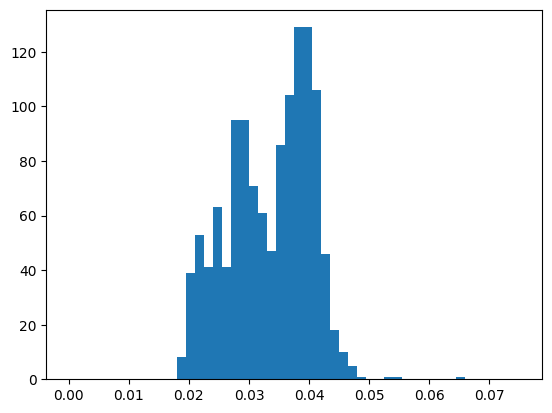

In [13]:
intervals = []
for i in range(poses_df.shape[0]-1):
    curr_time = poses_df.iloc[i]['timestamp']
    next_time = poses_df.iloc[i+1]['timestamp']
    intervals.append(next_time - curr_time)

plt.hist(intervals, range=(0, 0.075), bins=50)

In [14]:
def filter_skeleton(skeletons_list, user_id, keep_joints=KEEP_JOINTS):
    '''
    Filter the pose data to contain only the user specified by `user_id`.
    Filter `user_id` skeleton to contain only desired joints (defined by keep_joints).
    Return dicitonary object of remaining pose data.

    poses_df['skeletons'] is a list of json objects, with each element
    corresponding to a different "user" from the original video
    '''
    for skeleton in skeletons_list:
        # filter by user_id
        if skeleton['user_id'] == user_id:
            # filter by desired joints
            return {joint: skeleton[joint] for joint in skeleton if joint in keep_joints}

def bucketize_pose_data(poses_df, start_t, delta_t=DELTA_T, keep_joints=KEEP_JOINTS,
                        keep_measurements_dict=KEEP_MEASUREMENTS_DICT):
    '''
    Re-discretize the pose data into more regular time buckets for the purpose
    of easier temporal alignment with force data, text data, etc.

    Current strategy: use a fixed time interval between time buckets, with each
    bucket containing the averaged data of each timestamp in the range
    [bucket_t, bucket_t + delta_t) for bucket start time bucket_t. Averaged
    measurements are defined by keep_measurements
    '''
    curr_bucket = start_t

    records = []

    curr_record = {
        'timestamp': curr_bucket,
        'skeletons': {
            joint: {
                measurement: np.zeros(keep_measurements_dict[measurement])
                for measurement in keep_measurements_dict
            } for joint in keep_joints
        }
    }

    bucket_count = 0
    for ix, row in poses_df.iterrows():
        if row['timestamp'] < curr_bucket + delta_t:
            # sum up data for each measurement, for each joint
            for joint in keep_joints:
                for measurement in keep_measurements_dict:
                    curr_record['skeletons'][joint][measurement] += np.array(row['skeletons'][joint][measurement])
            bucket_count += 1

        else:
            # divide accumulated coordinates by bucket_count to get average of data
            for joint in keep_joints:
                for measurement in keep_measurements_dict:
                    assert bucket_count > 0
                    curr_record['skeletons'][joint][measurement] /= bucket_count

            # append curr_record to records
            records.append(curr_record)

            # update curr_bucket, create new curr_record, and reset bucket_count
            curr_bucket += delta_t
            curr_record = {
                'timestamp': curr_bucket,
                'skeletons': {
                    joint: {
                        measurement: np.zeros(keep_measurements_dict[measurement])
                        for measurement in keep_measurements_dict
                    } for joint in keep_joints
                }
            }
            bucket_count = 0

    return pd.DataFrame.from_records(records)

def preprocess_pose_data(poses_df, user_id):
    '''
    1. Filter out skeleton data by user_id and keep_joints
    2. Bucketize time serialized data into discrete buckets for alignment
    (see respective functions for more detailed descriptions)
    '''
    poses_df['skeletons'] = poses_df['skeletons'].apply(filter_skeleton, args=[user_id])
    poses_df = bucketize_pose_data(poses_df, 1707358708.6) # HARDCODED
    return poses_df


t = poses_df.copy(deep=True)
# t['skeletons'] = t['skeletons'].apply(filter_skeleton, args=[1])

# for i in range(10):
#     print(t.iloc[i]['timestamp'])
#     print(json.dumps(t.iloc[i]['skeletons'], indent=2))
#     print()

# for i in range(10):
#     print(t.iloc[i]['timestamp'])
#     print(t.iloc[i]['skeletons']['ShoulderRight']['orientation'])
#     print()

# t = bucketize_poses(t, 1707358708.6)

t = preprocess_pose_data(t, user_id=1)

# print('#####')
# for i in range(2):
#     print(t.iloc[i]['timestamp'])
#     print(t.iloc[i]['skeletons']['ShoulderRight']['pos2D'])
#     print()

for i in range(10):
    print(t.iloc[i]['timestamp'])
    print(json.dumps(t.iloc[i]['skeletons'], indent=2, cls=NumpyEncoder))
    print('\n\n\n')

1707358708.6
{
  "ShoulderRight": {
    "pos2D": [
      246.7530334,
      245.1374022
    ],
    "pos3D": [
      -0.16492401680000002,
      -0.0005760762600000001,
      1.258703948
    ],
    "orientation": [
      -0.12113017000000001,
      0.22346505419999999,
      0.8393982458,
      0.48009756580000007
    ]
  },
  "ElbowRight": {
    "pos2D": [
      208.40653379999998,
      303.65194
    ],
    "pos3D": [
      -0.23545559200000002,
      0.11594433180000001,
      1.21749924
    ],
    "orientation": [
      0.7299701346,
      0.5117878064,
      0.1972791878,
      0.4074248842
    ]
  },
  "WristRight": {
    "pos2D": [
      189.3614226,
      344.63448780000004
    ],
    "pos3D": [
      -0.2461625754,
      0.17770082360000003,
      1.096800232
    ],
    "orientation": [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  },
  "ShoulderLeft": {
    "pos2D": [
      351.3426488,
      244.1492472
    ],
    "pos3D": [
      0.05210945496,
      -0.002360263088,
  

In [15]:
USER_ID = 1
poses_df = preprocess_pose_data(poses_df, user_id=USER_ID)

for i in range(10):
    print(poses_df.iloc[i]['timestamp'])
    print(poses_df.iloc[i]['skeletons']['ShoulderRight']['pos2D'])

# poses_df.head()

1707358708.6
[246.7530334 245.1374022]
1707358708.8
[245.9368126 245.2358738]
1707358709.0
[245.4449514 245.272757 ]
1707358709.2
[245.375179  245.2192622]
1707358709.4
[245.3403028 245.1792108]
1707358709.6000001
[245.3533476 245.0888034]
1707358709.8000002
[245.3249252 245.0629518]
1707358710.0000002
[245.2999702 245.0402666]
1707358710.2000003
[245.2779182 245.0201638]
1707358710.4000003
[245.2582094 245.0022544]


In [16]:
poses_df.head()

,timestamp,skeletons
0,1.707359e+09,"{'ShoulderRight': {'pos2D': [246.7530334, 245...."
1,1.707359e+09,{'ShoulderRight': {'pos2D': [245.9368126000000...
2,1.707359e+09,{'ShoulderRight': {'pos2D': [245.4449514000000...
3,1.707359e+09,{'ShoulderRight': {'pos2D': [245.3751789999999...
4,1.707359e+09,{'ShoulderRight': {'pos2D': [245.3403027999999...


## Force data processing

In [17]:
force_fp = f'{DATA_FP}/lightbuzz_table_1/cut_data.csv'
force_df = pd.read_csv(force_fp)
force_df.head()

,timestamp,reading
0,1.707359e+09,Reading: 0.4 lbs
1,1.707359e+09,Reading: 0.4 lbs
2,1.707359e+09,Reading: 0.4 lbs
3,1.707359e+09,Reading: 0.4 lbs
4,1.707359e+09,Reading: 0.3 lbs


In [18]:
force_df.iloc[0]

timestamp    1707358708.69793
reading      Reading: 0.4 lbs
Name: 0, dtype: object

(array([ 2.,  0.,  1.,  1.,  0.,  0.,  1.,  0.,  4.,  4.,  2.,  6.,  3.,
        11.,  5., 10.,  5., 10., 18., 15., 21., 13., 31., 25., 36., 37.,
        41., 43., 31., 22.,  8.,  7.,  6.,  4.,  5.,  8.,  7.,  7.,  5.,
        10.,  2.,  3.,  3.,  2.,  2.,  0.,  0.,  0.,  0.,  1.]),
 array([0.08248997, 0.08270017, 0.08291038, 0.08312058, 0.08333078,
        0.08354099, 0.08375119, 0.0839614 , 0.0841716 , 0.0843818 ,
        0.08459201, 0.08480221, 0.08501242, 0.08522262, 0.08543283,
        0.08564303, 0.08585323, 0.08606344, 0.08627364, 0.08648385,
        0.08669405, 0.08690425, 0.08711446, 0.08732466, 0.08753487,
        0.08774507, 0.08795527, 0.08816548, 0.08837568, 0.08858589,
        0.08879609, 0.0890063 , 0.0892165 , 0.0894267 , 0.08963691,
        0.08984711, 0.09005732, 0.09026752, 0.09047772, 0.09068793,
        0.09089813, 0.09110834, 0.09131854, 0.09152874, 0.09173895,
        0.09194915, 0.09215936, 0.09236956, 0.09257977, 0.09278997,
        0.09300017]),
 <BarContainer

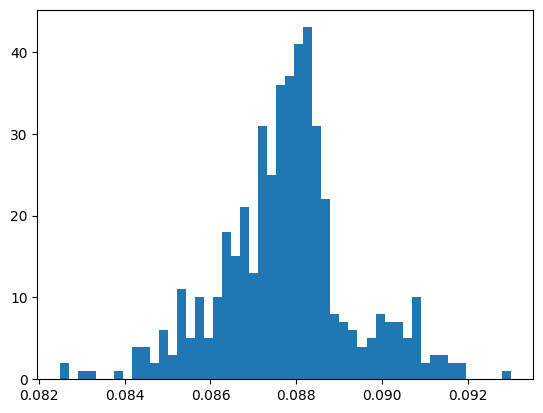

In [19]:
intervals = []
for i in range(force_df.shape[0]-1):
    curr_time = force_df.iloc[i]['timestamp']
    next_time = force_df.iloc[i+1]['timestamp']
    intervals.append(next_time - curr_time)

plt.hist(intervals, bins=50)

In [20]:
def filter_reading(reading):
    '''
    Filter the force reading data to contain only the float measurement.
    E.g., convert the original format of "Reading: 0.4 lbs" to "0.4" as a float
    '''
    pattern = 'Reading: (-?\d+(\.\d+)?) lbs'
    match = re.match(pattern, reading)
    return float(match.group(1))

def bucketize_force_data(force_df, start_t, delta_t=DELTA_T):
    '''
    Re-discretize the force data into more regular time buckets for the purpose
    of easier temporal alignment with pose data, text data, etc.

    Current strategy: use a fixed time interval between time buckets, with each
    bucket containing the averaged data of each timestamp in the range
    [bucket_t, bucket_t + delta_t) for bucket start time bucket_t. Averaged
    measurements are defined by keep_measurements
    '''
    curr_bucket = start_t

    records = []

    curr_record = {
        'timestamp': curr_bucket,
        'reading': 0.0
    }

    bucket_count = 0
    for ix, row in force_df.iterrows():
        if row['timestamp'] < curr_bucket + delta_t:
            # sum up force readings within time bucket
            curr_record['reading'] += row['reading']
            bucket_count += 1

        else:
            # divide accumulated coordinates by bucket_count to get average of data
            curr_record['reading'] /= bucket_count

            # append curr_record to records
            records.append(curr_record)

            # update curr_bucket, create new curr_record, and reset bucket_count
            curr_bucket += delta_t
            curr_record = {
                'timestamp': curr_bucket,
                'reading': 0.0
            }
            bucket_count = 0

    return pd.DataFrame.from_records(records)

def preprocess_force_data(force_df):
    '''
    1. Filter force readings to only contain numeric measurement
    2. Bucketize time serialized data into discrete buckets for alignment
    (see respective functions for more detailed descriptions)
    '''
    force_df['reading'] = force_df['reading'].apply(filter_reading)
    force_df = bucketize_force_data(force_df, 1707358708.6) # HARDCODED
    return force_df

t = force_df.copy(deep=True)
# t['reading'] = t['reading'].apply(filter_reading)

# t = bucketize_force_data(t, 1707358708.6)

t = preprocess_force_data(t)

for i in range(10):
    print(t.iloc[i]['timestamp'])
    print(t.iloc[i]['reading'])
    print()

1707358708.6
0.4

1707358708.8
0.4

1707358709.0
0.2

1707358709.2
-0.05

1707358709.4
0.0

1707358709.6000001
0.0

1707358709.8000002
0.0

1707358710.0000002
0.1

1707358710.2000003
0.2

1707358710.4000003
0.2



In [21]:
force_df = preprocess_force_data(force_df)

for i in range(10):
    print(force_df.iloc[i]['timestamp'])
    print(force_df.iloc[i]['reading'])
    print()

1707358708.6
0.4

1707358708.8
0.4

1707358709.0
0.2

1707358709.2
-0.05

1707358709.4
0.0

1707358709.6000001
0.0

1707358709.8000002
0.0

1707358710.0000002
0.1

1707358710.2000003
0.2

1707358710.4000003
0.2



## Alignment

In [22]:
t = torch.tensor([1.0, 2.0])
t.dtype

torch.float32

In [23]:
# convert feature dataframes into tensors
poses_tensor = torch.tensor(
    [
        [value for joint in skeleton for measurement in skeleton[joint] for value in skeleton[joint][measurement]]
        for skeleton in poses_df['skeletons']
    ]
)
force_tensor = torch.tensor(force_df['reading']).reshape((-1, 1))
text_tensor = torch.tensor(text_df['text']).reshape((-1, 1))
# pad text_df as necessary to match length of pose and force df
# TODO: replace padding with silence token, current 0 = [PAD] (is this ok? better to have specific silence token?)
text_tensor = torch.cat((text_tensor, torch.zeros(poses_tensor.shape[0] - text_tensor.shape[0], 1)), dim=0).long()

# !!! feature list of all feature tensors, add all used features here !!!
feature_tensors = [
    # text_tensor,
    poses_tensor,
    force_tensor,
]

# check that all dataframes are the same length
assert len(set([tensor.shape[0] for tensor in feature_tensors])) == 1, f'feature DataFrames have different lengths: {[len(tensor) for tensor in feature_tensors]}'

# arrange data in a single pytorch tensor
# columns represent various features (pose data, joint data, etc), rows represent time sequential data
num_features = sum(tensor.shape[1] for tensor in feature_tensors)
conv_input = torch.cat(feature_tensors, dim=1)
assert conv_input.shape[1] == num_features

# # reshape for batch dim first?
# conv_input = conv_input.unsqueeze(0)

# conv requires shape (B, C_in, L_in)
# conv_input = conv_input.permute(0,2,1)
conv_input = conv_input.permute(1,0)
conv_input.shape

# TODO: add positional embedding

torch.Size([55, 210])

# Convolution

In [24]:
d_model = 64

conv_config = {
    'in_channels': conv_input.shape[0],
    'out_channels': d_model,
    'kernel_size': 3,
    'stride': 1,
    'padding': 1,
    'dilation': 1,
    'bias': False
}

conv_model = nn.Sequential(
    nn.Conv1d(**conv_config),
    nn.ReLU(),
    # nn.BatchNorm1d(64), # debug
    # nn.Flatten()
)
conv_model.double()

Sequential(
  (0): Conv1d(55, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
  (1): ReLU()
)

In [25]:
conv_output = conv_model(conv_input)
conv_output.shape

torch.Size([64, 210])

# Transformer

## Offline transformer

In [26]:
transformer_decoder_layer_config = {
    'd_model': d_model,
    'nhead': 8,
    'batch_first': True,
}
transformer_decoder_layer = nn.TransformerDecoderLayer(**transformer_decoder_layer_config).double()

transformer_decoder_config = {
    'decoder_layer': transformer_decoder_layer,
    'num_layers': 6,
}
transformer_decoder = nn.TransformerDecoder(**transformer_decoder_config)
transformer_decoder.double()

embedding_layer = nn.Embedding(len(tokenizer), d_model)
fc_layer = nn.Linear(d_model, len(tokenizer)).double()

In [27]:
transformer_config = {
    'd_model': d_model,
    'nhead': 8,
    'num_encoder_layers': 6,
    'num_decoder_layers': 6,
    'batch_first': True,
}
transformer_model = nn.Transformer(**transformer_config)
transformer_model.double()

Transformer(
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_featu

In [28]:
transformer_target = embedding_layer(text_tensor.squeeze()).double()
print(f'{transformer_target.shape=}')
transformer_input = conv_output.transpose(1,0)
print(f'{transformer_input.shape=}')

# transformer_output = transformer_decoder(transformer_input, transformer_target)
transformer_output = transformer_model(transformer_input, transformer_target)
transformer_output = fc_layer(transformer_output)
transformer_output.shape

transformer_target.shape=torch.Size([210, 64])
transformer_input.shape=torch.Size([210, 64])


torch.Size([210, 30522])

### Dataset + DataLoaders 
(reorganize data processing to move this above Transformer section)

In [29]:
class CombinedDataset(Dataset):
    def __init__(self, input_tensor, target_tensor):
        self.input = input_tensor.detach().clone()
        self.target = target_tensor.detach().clone()

        assert self.input.shape[0] == self.target.shape[0] # tensors are of the same length

    def __len__(self):
        return self.input.shape[0]

    def __getitem__(self, ix):
        return self.input[ix], self.target[ix]

In [30]:
dataset = CombinedDataset(transformer_input, transformer_target)
dataset[0]

(tensor([0.0000e+00, 0.0000e+00, 5.1797e+01, 2.0026e+01, 4.5653e+01, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 1.1031e+02, 0.0000e+00, 3.1526e+01, 1.3732e+02,
         0.0000e+00, 0.0000e+00, 6.6383e+01, 1.4099e+02, 0.0000e+00, 3.4039e+01,
         0.0000e+00, 0.0000e+00, 4.5057e+01, 0.0000e+00, 1.1181e-01, 0.0000e+00,
         2.8727e+01, 0.0000e+00, 1.4472e+02, 1.4337e+00, 8.1396e+01, 7.6436e+01,
         1.3061e+02, 7.2767e+01, 7.1252e+01, 0.0000e+00, 0.0000e+00, 5.0173e+01,
         0.0000e+00, 0.0000e+00, 9.6426e+01, 1.2621e+02, 0.0000e+00, 3.8509e+01,
         0.0000e+00, 7.7812e+01, 1.0551e+01, 1.1589e+01, 0.0000e+00, 5.4749e+00,
         4.2517e+01, 6.8277e+01, 3.3493e+01, 1.1748e+01, 4.2927e+01, 1.2339e+01,
         0.0000e+00, 0.0000e+00, 1.5895e+01, 4.4547e+01, 0.0000e+00, 5.5568e+00,
         2.3224e+01, 5.4567e+01, 7.4659e+00, 0.0000e+00], dtype=torch.float64),
 tensor([ 0.3351,  2.3786,  0.3297, -0.6348, -1.0766, -0.3513, -0.0583,  1.8314,
          0.8590,  0.7416,  1

In [31]:
train_loader = DataLoader(dataset, batch_size=16, shuffle=False)

In [32]:
# TODO: optimize more than just transformer

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

def train(model, train_loader, val_loader=None, num_epochs=20, loss_fn=nn.CrossEntropyLoss, optimizer=torch.optim.Adam,
          lr=0.001, weight_decay=0):

    loss_fn = loss_fn()
    optimizer = optimizer(model.parameters(), lr, weight_decay=weight_decay)

    lossi = []
    val_lossi = []

    model.to(device)
    loss_fn.to(device)

    # Train the model
    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        step_loss = []
        for i, (features, target) in tqdm.tqdm(enumerate(train_loader)):
            features, target = features.to(device), target.to(device)
            out = model(features, target)
            loss = loss_fn(out, target)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            step_loss.append(loss.item())
            epoch_train_loss += loss.item()

        lossi.append(np.mean(step_loss))

        # Evaluate loss on validation set
        model.eval()
        epoch_val_loss = 0
        # with torch.no_grad():
        #     step_loss = []
        #     for i, (data, target) in enumerate(val_loader):
        #         data, target = data.to(device), target.to(device)
        #         out = model(data)
        #         loss = loss_fn(out, target)

        #         step_loss.append(loss.item())
        #         epoch_val_loss += loss.item()
        # val_lossi.append(np.mean(step_loss))

        # print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_train_loss / len(train_loader)} / {epoch_val_loss / len(val_loader)}')
        # print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_train_loss / len(train_loader)}')

    return lossi, val_lossi

In [33]:
train(transformer_model, train_loader)

14it [00:01, 11.73it/s]
14it [00:01, 12.93it/s]
14it [00:01,  9.70it/s]
14it [00:01,  9.48it/s]
14it [00:01, 13.33it/s]
14it [00:01, 11.65it/s]
14it [00:01,  8.59it/s]
14it [00:02,  5.88it/s]
14it [00:03,  4.41it/s]
14it [00:03,  3.94it/s]
14it [00:02,  5.61it/s]
14it [00:02,  4.89it/s]
14it [00:01,  8.49it/s]
14it [00:01,  9.92it/s]
14it [00:01, 10.56it/s]
14it [00:01, 10.55it/s]
14it [00:01, 11.56it/s]
14it [00:01, 12.89it/s]
14it [00:01, 12.27it/s]
14it [00:01, 12.14it/s]


([-14.567420764358944,
  -25.772593320951813,
  -37.41134360702824,
  -43.11150947389469,
  -42.601375274754055,
  -49.8997776338935,
  -53.350680160033455,
  -54.89541731542295,
  -59.74157696528094,
  -63.87240910801544,
  -66.5316054154366,
  -68.3935092805726,
  -70.68598099406023,
  -73.85497886306872,
  -75.53162734250894,
  -77.50636775295688,
  -80.69685499520074,
  -81.44859006462043,
  -83.44107505611659,
  -85.63276338312058],
 [])

In [34]:
def decode(model, data, target):
    out = model(data, target)
    out = fc_layer(out)
    print(out.shape)
    out = torch.softmax(out, dim=1)
    out = torch.argmax(out, dim=1)
    return tokenizer.batch_decode(out)

In [35]:
decode(transformer_model, transformer_input, transformer_target)

torch.Size([210, 30522])


['##ds',
 '##ds',
 'usaf',
 'usaf',
 'usaf',
 'ventured',
 'ventured',
 '##landa',
 '##landa',
 '##ess',
 '##ess',
 '##ess',
 'glossy',
 'enduring',
 'stealing',
 '##fb',
 '##ror',
 'hesse',
 'hesse',
 'hesse',
 '##drick',
 '##drick',
 '##drick',
 '##drick',
 '##drick',
 '##drick',
 'fluttering',
 'fluttering',
 'fluttering',
 '##landa',
 '##landa',
 'hesse',
 'hesse',
 'emptied',
 'fluttering',
 'fluttering',
 'fluttering',
 'fluttering',
 '##landa',
 '##landa',
 'hesse',
 'hesse',
 'emptied',
 'stealing',
 'stealing',
 'stealing',
 'stealing',
 '##aly',
 'प',
 'hesse',
 'expired',
 'expired',
 'expired',
 'expired',
 'glossy',
 'enduring',
 'stealing',
 'nordic',
 'hopper',
 'hopper',
 '##場',
 '##場',
 'hesse',
 'hesse',
 'hesse',
 'hesse',
 'printing',
 'printing',
 'printing',
 'printing',
 'hesse',
 'hesse',
 'convicted',
 '##beat',
 '##beat',
 '##beat',
 '##beat',
 '##beat',
 'nordic',
 'hesse',
 'hesse',
 'printing',
 'printing',
 'printing',
 'nordic',
 'nordic',
 'nordic',
 'no

## Online transformer

Strategy:
* start server to collect data
* collect data for a specified amount of time (eg. one second)
* after enough data collected, preprocess all data for convolution input
* produce word output from transformer

In [36]:
import multiprocessing as mp
from ..lightbuzz_poses import collect_poses

def real_time_transformer():

    time_interval = 1

    q = mp.Queue()
    proc_collect = mp.Process(target=collect_poses, args=(q,))
    proc_collect.start()

    while True:
        timestamp, poses_data = q.get()
        curr_time = timestamp // time_interval * time_interval

        if timestamp > curr_time + time_interval:
            poses_df = preprocess_pose_data(poses_df, user_id=1)
            force_df = preprocess_force_data(force_df)

            conv_input = align_data(poses_df, force_df)
            conv_output = conv_model(conv_input)

            transformer_input = conv_output.transpose(1,0)
            transformer_target = embedding_layer(text_tensor.squeeze()).double()

            transformer_output = transformer_model(transformer_input, transformer_target)
            transformer_output = fc_layer(transformer_output)

            output = transformer_model.decode(conv_output)
            print(tokenizer.deocde(output))

            curr_time += time_interval

ImportError: attempted relative import with no known parent package

# Scribble

In [135]:
# 1707358708.8
# 1707358750.0000098

a = 1707358708.8
b = 1707358750.0000098

p = poses_df.iloc[
    poses_df.index[poses_df['timestamp'] == a][0] : poses_df.index[poses_df['timestamp'] == b][0]
]
print(len(poses_df), len(p))

210 206


In [146]:
tokenizer.decode(0)

'[PAD]'